In [1]:
import siamese_torch2 as st 
import siamese_models as sm
import torch
from glob import glob
from PIL import Image
import utils as ut
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms as T

from natsort import natsorted 
import json

2024-11-04 09:57:36.717607: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 09:57:36.749047: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 09:57:36.749072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 09:57:36.750015: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 09:57:36.755626: I tensorflow/core/platform/cpu_feature_guar

In [2]:

pathmob = "models/siamese_network_mobnet.pt"
pathres = "models/siamese_network_resnet.pt"

In [ ]:
resnet = st.SiameseNetworkResnet()
resnet.load_state_dict(torch.load(pathres))
resnet.eval()


In [6]:
ds = ut.siamese_noise_dataset_new(shuffle=True, noise_size='mid')
val_loader = torch.utils.data.DataLoader(ds['valid'].with_format("torch"), batch_size=32)

resnet.eval()
test_loss, correct = 0, 0
criterion = nn.BCELoss()

device = torch.device("cuda")
resnet.to(device)
with torch.no_grad():
    for i in val_loader:
        images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1)
        images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1)
        targets = i['label'].to(device, dtype=torch.float32)

        outputs = resnet(images_1, images_2).squeeze()
        test_loss += criterion(outputs, targets).sum().item()  # sum up batch loss

        pred = torch.where(outputs > 0.5, 1, 0)  # get the index of the max log-probability
        correct += pred.eq(targets.view_as(pred)).sum().item()

test_loss /= len(val_loader.dataset)
test_accuracy = 100. * correct / len(val_loader.dataset)
print(f'\nTest set: Average loss: {test_loss:.4f}, \
        Accuracy: {correct}/{len(val_loader.dataset)} ({test_accuracy:.0f}%)\n')


Test set: Average loss: 0.0000,         Accuracy: 315/315 (100%)



In [20]:
batchval = next(iter(val_loader))
batchval['slice1'][0].shape
batchval['slice2'][0].shape

torch.Size([224, 224])

In [22]:
resnet(batchval['slice1'][0].unsqueeze(1), batchval['slice2'][0].unsqueeze(1))

RuntimeError: Given groups=1, weight of size [64, 1, 7, 7], expected input[1, 224, 1, 224] to have 1 channels, but got 224 channels instead

In [ ]:
mobnet = st.SiameseNetworkMobnet()
mobnet.load_state_dict(torch.load(pathmob))
mobnet.eval()

In [6]:
tumor_dir_no = "../siamese/data/brain_tumor_dataset/no/"
tumor_dir_yes = "../siamese/data/brain_tumor_dataset/yes/"

tumor_no = glob(tumor_dir_no + "*")
tumor_yes = glob(tumor_dir_yes + "*")

pil_tumor_no = [Image.open(i) for i in tumor_no]
pil_tumor_yes = [Image.open(i) for i in tumor_yes]

In [ ]:
shapes = {}
for i in pil_tumor_no:
    shapes[i.size] = 0 
shapes

In [8]:
im = pil_tumor_no[0]
(width, height ) = im.size
line0 = [{'x': width/5, 'y': height/2}, {'x': width/5*4, 'y': height/2+0.5}]
line0 = str(line0)
line0

"[{'x': 46.0, 'y': 141.0}, {'x': 184.0, 'y': 141.5}]"

In [11]:
edge_points = ut.non_zeros(im, plot=False)
transparent_img = ut.segment2(im, edge_points)
# rotated_img = ut.rotate(transparent_img, line0, show_line=True)
rotated_img = ut.rotate(transparent_img.rotate(-90), line0, show_line=False)
slice1, slice2 = ut.slice_aligned(rotated_img)
slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)


# display(im)
# display(transparent_img)
# display(im.rotate(-90))
# display(rotated_img)
# display(slice1)
# display(slice2)

In [13]:
for im_no in pil_tumor_no[:10]:
    (width, height ) = im.size
    line = [{'x': width/5, 'y': height/2}, {'x': width/5*4, 'y': height/2+0.5}]
    line = str(line)
    # display(im_no.rotate(-90))
    edge_points = ut.non_zeros(im, plot=False)
    transparent_img = ut.segment2(im, edge_points)
    # we rotate here
    rotated_img = ut.rotate(transparent_img.rotate(-90), line, show_line=False)
    slice1, slice2 = ut.slice_aligned(rotated_img)
    slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)

In [14]:
def siamese_dataset_inference(rgb=False):
    """
    siamese_dataset for inference test
    """

    i = 0
    pairs, labels = [], [0]*len(pil_tumor_no)

    if rgb: mode = 'RGB'
    else: mode = 'L'


    for im_no in pil_tumor_no[:]:
        (width, height ) = im_no.size
        line = [{'x': width/5, 'y': height/2}, {'x': width/5*4, 'y': height/2+0.5}]
        line = str(line)
        # display(im_no.rotate(-90))
        edge_points = ut.non_zeros(im_no, plot=False)
        transparent_img = ut.segment2(im_no, edge_points)
        # we rotate here
        rotated_img = ut.rotate(transparent_img.rotate(-90), line, show_line=False)
        slice1, slice2 = ut.slice_aligned(rotated_img)
        slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)

        # add noise option

        slice2, slice1 = slice2.convert(mode), slice1_rot.convert(mode)

        slice2, slice1 = slice2.resize((290, 145)), slice1.resize((290, 145))

        pairs += [[np.array(slice2), np.array(slice1)]]

        i+=1

    pairs, labels = np.array(pairs), np.array(labels).astype("float32")

    return pairs, labels


In [15]:
pairs_no, labels_no = siamese_dataset_inference()

In [16]:
pairs_no.shape

(98, 2, 145, 290)

2024-08-19 14:00:17.168348: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46791 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:19:00.0, compute capability: 8.6
2024-08-19 14:00:17.168861: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46857 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:1b:00.0, compute capability: 8.6
2024-08-19 14:00:17.169309: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46657 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:68:00.0, compute capability: 8.6


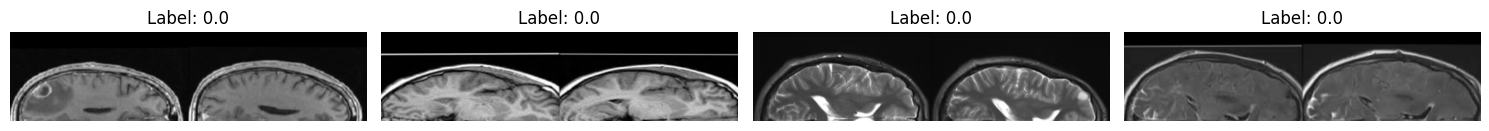

In [17]:
ut.visualize(pairs_no, labels_no, to_show=4, num_col=4)

In [18]:
class ImagePairDataset(torch.utils.data.Dataset):
    def __init__(self, arrays, labels, vit = False):
        if vit:
            self.transform = T.Compose([T.ToPILImage(), T.Resize((224,224)), T.ToTensor()])
        else:
            self.transform = T.Compose([T.ToPILImage(), T.Resize((256,256)), T.ToTensor()])
        self.arrays = arrays
        self.labels = labels
        self.image_pairs = self.load_image_pairs()

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        # image1, image2 = torch.from_numpy(self.arrays[idx][0]), torch.from_numpy(self.arrays[idx][1])
        image1 = self.transform(self.arrays[idx][0])
        image2 = self.transform(self.arrays[idx][1])
        label = torch.as_tensor(self.labels[idx])

        return image1, image2, label

    def load_image_pairs(self):
        image_pairs = [torch.from_numpy(i) for i in self.arrays]
        # image_labels = [i for i in self.labels]
        return image_pairs

Eval on NO 

In [19]:
test_dataset = ImagePairDataset(pairs_no, labels_no, vit=False)
test_loader = torch.utils.data.DataLoader(test_dataset)

In [20]:
device = torch.device("cuda")

In [24]:
resnet.eval().to(device)
test_loss = 0
correct = 0

criterion = nn.BCELoss()

with torch.no_grad():
    for (images_1, images_2, targets) in test_loader:
        images_1, images_2, targets = images_1.to(device), images_2.to(device), targets.to(device)
        outputs = resnet(images_1, images_2).squeeze()
        # print(targets[0])
        # print(outputs)
        test_loss += criterion(outputs, targets[0]).sum().item()  # sum up batch loss
        pred = torch.where(outputs > 0.5, 1, 0)  # get the index of the max log-probability
        correct += pred.eq(targets.view_as(pred)).sum().item()

test_loss /= len(test_loader.dataset)
test_accuracy = 100. * correct / len(test_loader.dataset)
print(f'\nTest set: Average loss: {test_loss:.4f}, \
        Accuracy: {correct}/{len(test_loader.dataset)} ({test_accuracy:.0f}%)\n')

test_loss, test_accuracy


Test set: Average loss: 8.7118,         Accuracy: 84/98 (86%)



(8.711794290647216, 85.71428571428571)

In [25]:
import matplotlib.pyplot as plt

Eval on YES

In [26]:
def siamese_dataset_inference_yes(rgb=False):
    """
    siamese_dataset for inference test
    """

    i = 0
    pairs, labels = [], [1.0]*len(pil_tumor_yes)

    if rgb: mode = 'RGB'
    else: mode = 'L'


    for im_yes in pil_tumor_yes[:]:
        (width, height ) = im_yes.size
        line = [{'x': width/5, 'y': height/2}, {'x': width/5*4, 'y': height/2+0.5}]
        line = str(line)
        # display(im_yes.rotate(-90))
        edge_points = ut.non_zeros(im_yes, plot=False)
        transparent_img = ut.segment2(im_yes, edge_points)
        # we rotate here
        rotated_img = ut.rotate(transparent_img.rotate(-90), line, show_line=False)
        slice1, slice2 = ut.slice_adjusted(rotated_img)
        slice1_rot = slice1.rotate(180).transpose(Image.FLIP_LEFT_RIGHT)

        # add noise option

        slice2, slice1 = slice2.convert(mode), slice1_rot.convert(mode)

        slice2, slice1 = slice2.resize((290, 145)), slice1.resize((290, 145))

        pairs += [[np.array(slice2), np.array(slice1)]]

        i+=1

    pairs, labels = np.array(pairs), np.array(labels).astype("float32")

    return pairs, labels


In [27]:
pairs_yes, labels_yes = siamese_dataset_inference_yes()

In [28]:
pairs_yes.shape

(155, 2, 145, 290)

In [29]:
test_dataset_yes = ImagePairDataset(pairs_yes, labels_yes, vit=False)
test_loader_yes = torch.utils.data.DataLoader(test_dataset_yes)

In [30]:
device = torch.device("cuda")

In [31]:
resnet.eval().to(device)
test_loss_yes = 0
correct = 0

criterion = nn.BCELoss()

with torch.no_grad():
    for (images_1, images_2, targets) in test_loader_yes:
        images_1, images_2, targets = images_1.to(device), images_2.to(device), targets.to(device)
        outputs = resnet(images_1, images_2).squeeze()
        # print(targets[0])
        # print(outputs)
        test_loss_yes += criterion(outputs, targets[0]).sum().item()  # sum up batch loss
        pred = torch.where(outputs > 0.5, 1, 0)  # get the index of the max log-probability
        correct += pred.eq(targets.view_as(pred)).sum().item()

test_loss_yes /= len(test_loader_yes.dataset)
test_accuracy_yes = 100. * correct / len(test_loader_yes.dataset)
print(f'\nTest set: Average loss: {test_loss_yes:.4f}, \
        Accuracy: {correct}/{len(test_loader_yes.dataset)} ({test_accuracy_yes:.0f}%)\n')

test_loss_yes, test_accuracy_yes


Test set: Average loss: 5.0810,         Accuracy: 55/155 (35%)



(5.080950374967009, 35.483870967741936)

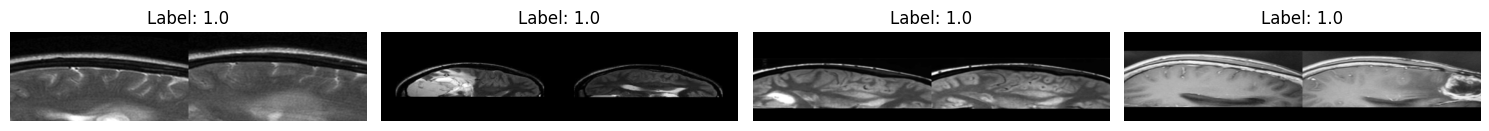

In [32]:
ut.visualize(pairs_yes, labels_yes, to_show=4, num_col=4)

Latest kaggle eval

In [2]:
pathvgg = "models/kfoldtest_lil2/VGGNet.pt"
vggnet = sm.SiameseNetworkVGGnetTest()
vggnet.load_state_dict(torch.load(pathvgg))
vggnet.eval()


SiameseNetworkVGGnetTest(
  (vggnet): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [1]:
from datasets import load_from_disk
dfl = load_from_disk("models/ds")
dfl['line'][9]

"[{'x': 258.3854, 'y': 456.699}, {'x': 258.4854, 'y': 91.9612}]"

In [4]:
ds = ut.siamese_noise_dataset_any(dfl)
ds

DatasetDict({
    test: Dataset({
        features: ['slice1', 'slice2'],
        num_rows: 51
    })
})

In [6]:

val_loader = torch.utils.data.DataLoader(ds['test'].with_format("torch"), batch_size=64)

vggnet.eval()
test_loss, correct = 0, 0
criterion = nn.BCELoss()

device = torch.device("cuda")
vggnet.to(device)
with torch.no_grad():
    for i in val_loader:
        images_1 = i['slice1'].to(device, dtype=torch.float32).unsqueeze(1)
        images_2 = i['slice2'].to(device, dtype=torch.float32).unsqueeze(1)
        # targets = i['label'].to(device, dtype=torch.float32)

        outputs = vggnet(images_1, images_2).squeeze()
        # test_loss += criterion(outputs, targets).sum().item()  # sum up batch loss

        pred = torch.where(outputs > 0.5, 1, 0)  # get the index of the max log-probability
        # correct += pred.eq(targets.view_as(pred)).sum().item()
        print(pred)

# test_loss /= len(val_loader.dataset)
# test_accuracy = 100. * correct / len(val_loader.dataset)
# print(f'\nTest set: Average loss: {test_loss:.4f}, \
#         Accuracy: {correct}/{len(val_loader.dataset)} ({test_accuracy:.0f}%)\n')

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0], device='cuda:0')


In [2]:
import matplotlib.pyplot as plt
plt.imshow(list(val_loader)[0]['slice1'][5])#.shape

NameError: name 'val_loader' is not defined

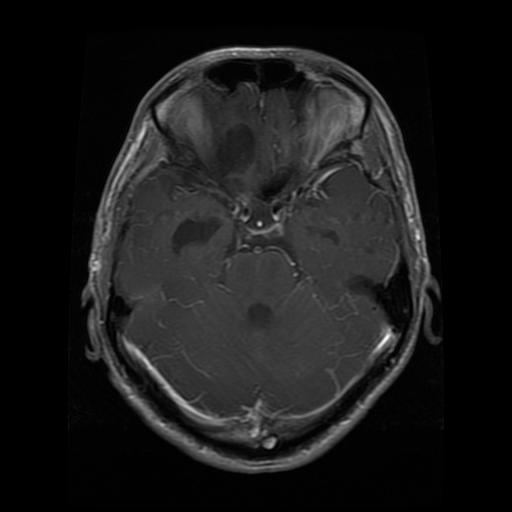

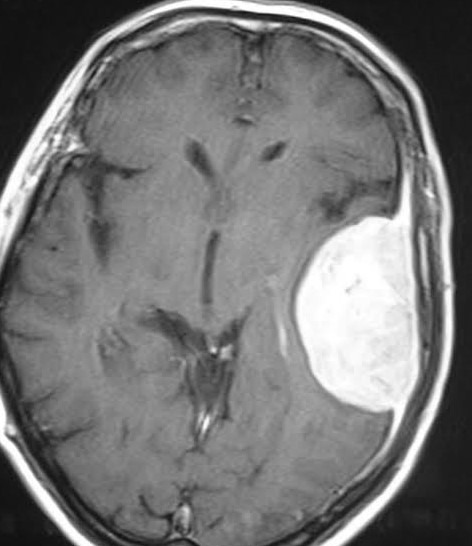

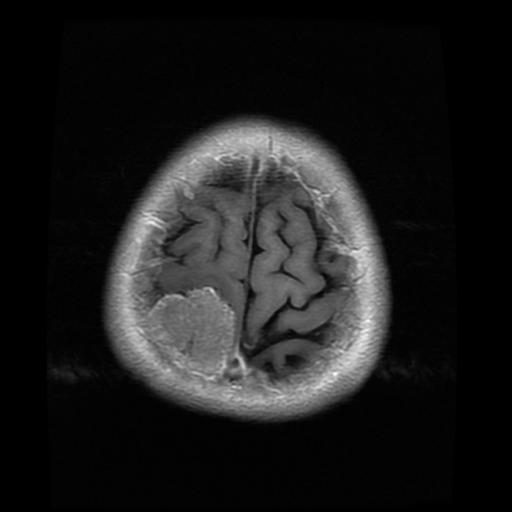

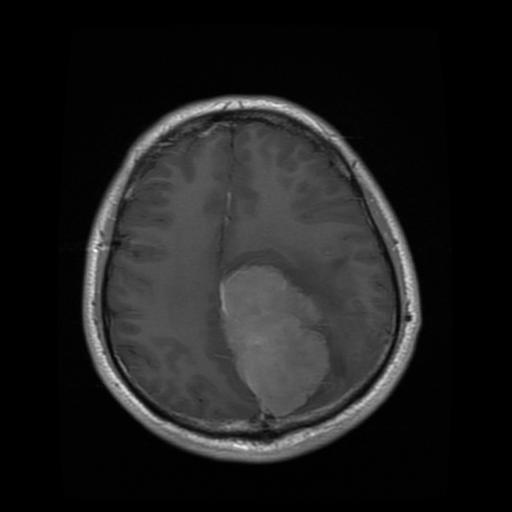

In [5]:
display(dfl['image'][5])
display(dfl['image'][16])
display(dfl['image'][21])
display(dfl['image'][26])